<a href="https://colab.research.google.com/github/tom22121/Ai-work/blob/AI-Homeworks-and-projects/Exercise_3_Ensemble_Learning_Thomas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3 - Order of Ensemble Learning

The objective of this exercise is to compare different ways of organizing the same total number of base decision trees (10).

For the Random Forest approach, I will compare:

- 1 forest of 10 trees
- 2 forests of 5 trees
- 5 forests of 2 trees

The experiments are performed on the Breast Cancer dataset from scikit-learn.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 1. Dataset

The Breast Cancer dataset is loaded from scikit-learn.
The objective is to classify tumors as malignant or benign.

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

In [ ]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", data.target_names)

Number of samples: 569
Number of features: 30
Classes: ['malignant' 'benign']


## 2. Train and test sets

The dataset is divided into training and testing data.

75% of the samples are used for training and 25% for testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 426
Testing samples: 143


## 3. Random Forest comparison

### 3.1 One forest with 10 trees

The first approach consists of one Random Forest containing 10 decision trees.

When two ensembles are combined, I average their predicted probabilities (soft voting) to avoid a possible tie. With five ensembles, a simple majority vote can be used.

In [ ]:
forest_10 = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

forest_10.fit(X_train, y_train);

In [ ]:
pred_1x10 = forest_10.predict(X_test)

In [ ]:
accuracy_1x10 = accuracy_score(y_test, pred_1x10)

print("Accuracy:", accuracy_1x10)

Accuracy: 0.951048951048951


### 3.2 Two forests with 5 trees each

The second approach uses two Random Forest models with 5 trees each.

Their predictions are then combined.

In [ ]:
forest_5_a = RandomForestClassifier(
    n_estimators=5,
    random_state=1
)

forest_5_b = RandomForestClassifier(
    n_estimators=5,
    random_state=2
)

forest_5_a.fit(X_train, y_train)
forest_5_b.fit(X_train, y_train);

Since the two forests can give different predictions, their predicted probabilities are averaged to obtain the final prediction.

In [ ]:
proba_a = forest_5_a.predict_proba(X_test)[:, 1]
proba_b = forest_5_b.predict_proba(X_test)[:, 1]

mean_proba = (proba_a + proba_b) / 2

pred_2x5 = (mean_proba >= 0.5).astype(int)

In [ ]:
accuracy_2x5 = accuracy_score(y_test, pred_2x5)

print("Accuracy:", accuracy_2x5)

Accuracy: 0.972027972027972


### 3.3 Five forests with 2 trees each

The third approach uses five Random Forest models with 2 trees each.

The final prediction is obtained using majority voting between the five forests.

In [ ]:
forests_2 = []

for i in range(5):
    forest = RandomForestClassifier(
        n_estimators=2,
        random_state=i
    )

    forest.fit(X_train, y_train)
    forests_2.append(forest)

In [ ]:
predictions = []

for forest in forests_2:
    predictions.append(forest.predict(X_test))

predictions = np.array(predictions)

With five forests, a majority vote can be used directly.  
At least three forests must predict class 1 for the final prediction to be class 1.

In [ ]:
pred_5x2 = (predictions.sum(axis=0) >= 3).astype(int)

In [ ]:
accuracy_5x2 = accuracy_score(y_test, pred_5x2)

print("Accuracy:", accuracy_5x2)

Accuracy: 0.9440559440559441


### 3.4 First comparison

The three approaches use the same total number of trees: 10.

I first compare their accuracy on the same train/test split.

In [ ]:
print("1 forest x 10 trees:", accuracy_1x10)
print("2 forests x 5 trees:", accuracy_2x5)
print("5 forests x 2 trees:", accuracy_5x2)

1 forest x 10 trees: 0.951048951048951
2 forests x 5 trees: 0.972027972027972
5 forests x 2 trees: 0.9440559440559441


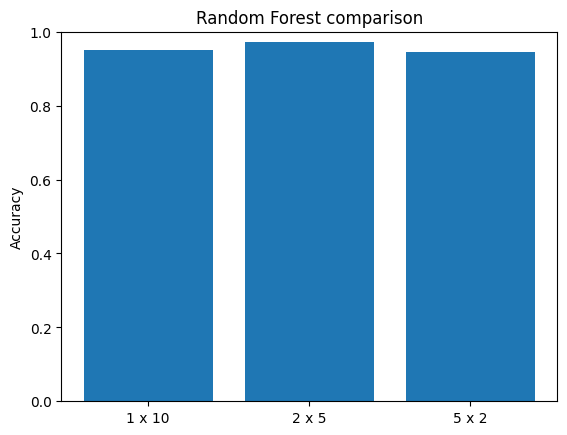

In [ ]:
names = [
    "1 x 10",
    "2 x 5",
    "5 x 2"
]

accuracies = [
    accuracy_1x10,
    accuracy_2x5,
    accuracy_5x2
]

plt.bar(names, accuracies)

plt.ylabel("Accuracy")
plt.title("Random Forest comparison")

plt.ylim(0, 1)

plt.show()

### 3.5 Repeated comparison

A single train/test split may give a result that depends on the random split.

To obtain a more reliable comparison, I repeat the experiment several times with different random seeds.

In [ ]:
results_1x10 = []
results_2x5 = []
results_5x2 = []

for seed in range(30):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=seed,
        stratify=y
    )

    # 1 forest x 10 trees
    forest_10 = RandomForestClassifier(
        n_estimators=10,
        random_state=seed
    )

    forest_10.fit(X_train, y_train)
    pred_1x10 = forest_10.predict(X_test)

    results_1x10.append(
        accuracy_score(y_test, pred_1x10)
    )

    # 2 forests x 5 trees
    forest_a = RandomForestClassifier(
        n_estimators=5,
        random_state=seed + 100
    )

    forest_b = RandomForestClassifier(
        n_estimators=5,
        random_state=seed + 200
    )

    forest_a.fit(X_train, y_train)
    forest_b.fit(X_train, y_train)

    proba_a = forest_a.predict_proba(X_test)[:, 1]
    proba_b = forest_b.predict_proba(X_test)[:, 1]

    mean_proba = (proba_a + proba_b) / 2

    pred_2x5 = (mean_proba >= 0.5).astype(int)

    results_2x5.append(
        accuracy_score(y_test, pred_2x5)
    )

    # 5 forests x 2 trees
    forests = []

    for i in range(5):

        forest = RandomForestClassifier(
            n_estimators=2,
            random_state=seed + 300 + i
        )

        forest.fit(X_train, y_train)
        forests.append(forest)

    predictions = []

    for forest in forests:
        predictions.append(
            forest.predict(X_test)
        )

    predictions = np.array(predictions)

    pred_5x2 = (
        predictions.sum(axis=0) >= 3
    ).astype(int)

    results_5x2.append(
        accuracy_score(y_test, pred_5x2)
    )

### 3.6 Results of the repeated comparison

For each configuration, I calculate the mean accuracy and the standard deviation over the 30 repetitions.

In [ ]:
print("1 forest x 10 trees")
print("Mean accuracy:", np.mean(results_1x10))
print("Standard deviation:", np.std(results_1x10))

print()

print("2 forests x 5 trees")
print("Mean accuracy:", np.mean(results_2x5))
print("Standard deviation:", np.std(results_2x5))

print()

print("5 forests x 2 trees")
print("Mean accuracy:", np.mean(results_5x2))
print("Standard deviation:", np.std(results_5x2))

1 forest x 10 trees
Mean accuracy: 0.9498834498834497
Standard deviation: 0.017790603173046326

2 forests x 5 trees
Mean accuracy: 0.9517482517482516
Standard deviation: 0.013553931711055116

5 forests x 2 trees
Mean accuracy: 0.9372960372960374
Standard deviation: 0.01981900376596733


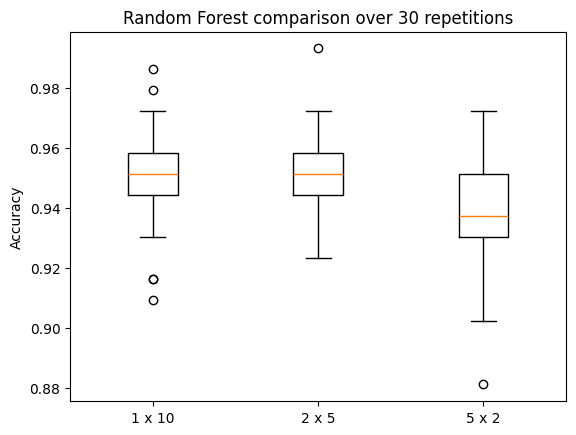

In [ ]:
plt.boxplot(
    [results_1x10, results_2x5, results_5x2],
    tick_labels=["1 x 10", "2 x 5", "5 x 2"]
)

plt.ylabel("Accuracy")
plt.title("Random Forest comparison over 30 repetitions")

plt.show()

Before comparing stacking and boosting, I restore the original train/test split (`random_state=42`) so that the models are evaluated on the same test set as in the initial Random Forest comparison.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

## 4. Stacking comparison

I now repeat the same comparison using stacking.

The base models are simple decision trees and the final model is a logistic regression.

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
def make_stacking(n_trees, seed):

    estimators = []

    for i in range(n_trees):

        tree = DecisionTreeClassifier(
            max_depth=1,
            splitter="random",
            random_state=seed + i
        )

        estimators.append(
            (f"tree_{i}", tree)
        )

    model = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000)
    )

    return model

The function creates a stacking model with a chosen number of simple decision trees.

The predictions of these trees are then combined by a logistic regression model.

### 4.1 One stacking model with 10 trees

The first stacking approach uses 10 simple decision trees as base models.
Their predictions are combined by the logistic regression meta-model.

In [ ]:
stack_10 = make_stacking(
    n_trees=10,
    seed=42
)

stack_10.fit(X_train, y_train)

pred_stack_1x10 = stack_10.predict(X_test)

accuracy_stack_1x10 = accuracy_score(
    y_test,
    pred_stack_1x10
)

print("Accuracy:", accuracy_stack_1x10)

Accuracy: 0.9230769230769231


### 4.2 Two stacking models with 5 trees each

Two separate stacking models are trained.
Their final predicted probabilities are averaged to obtain one final prediction.

In [ ]:
stack_a = make_stacking(5, 100)
stack_b = make_stacking(5, 200)

stack_a.fit(X_train, y_train)
stack_b.fit(X_train, y_train)

proba_a = stack_a.predict_proba(X_test)[:, 1]
proba_b = stack_b.predict_proba(X_test)[:, 1]

mean_proba = (proba_a + proba_b) / 2

pred_stack_2x5 = (
    mean_proba >= 0.5
).astype(int)

accuracy_stack_2x5 = accuracy_score(
    y_test,
    pred_stack_2x5
)

print("Accuracy:", accuracy_stack_2x5)

Accuracy: 0.9230769230769231


### 4.3 Five stacking models with 2 trees each

Five small stacking models are trained.
Their final predictions are combined using majority voting.

In [ ]:
stack_models = []

for i in range(5):

    model = make_stacking(
        n_trees=2,
        seed=300 + i
    )

    model.fit(X_train, y_train)
    stack_models.append(model)

In [ ]:
stack_predictions = []

for model in stack_models:
    stack_predictions.append(
        model.predict(X_test)
    )

stack_predictions = np.array(
    stack_predictions
)

pred_stack_5x2 = (
    stack_predictions.sum(axis=0) >= 3
).astype(int)

accuracy_stack_5x2 = accuracy_score(
    y_test,
    pred_stack_5x2
)

print("Accuracy:", accuracy_stack_5x2)

Accuracy: 0.9370629370629371


### 4.4 Stacking results

I compare the three stacking configurations using the same test set.

In [ ]:
print("1 stacking x 10 trees:", accuracy_stack_1x10)
print("2 stacking x 5 trees:", accuracy_stack_2x5)
print("5 stacking x 2 trees:", accuracy_stack_5x2)

1 stacking x 10 trees: 0.9230769230769231
2 stacking x 5 trees: 0.9230769230769231
5 stacking x 2 trees: 0.9370629370629371


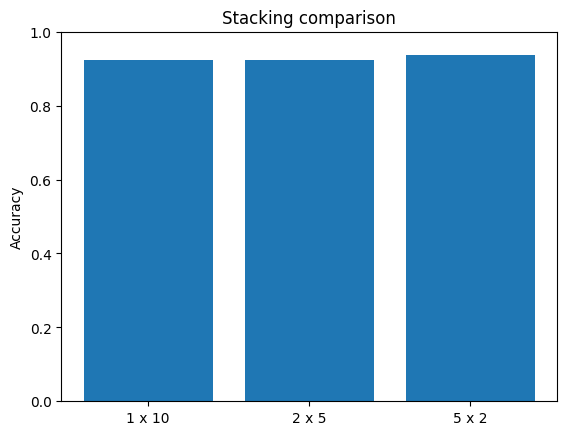

In [ ]:
names = [
    "1 x 10",
    "2 x 5",
    "5 x 2"
]

stack_accuracies = [
    accuracy_stack_1x10,
    accuracy_stack_2x5,
    accuracy_stack_5x2
]

plt.bar(names, stack_accuracies)

plt.ylabel("Accuracy")
plt.title("Stacking comparison")

plt.ylim(0, 1)

plt.show()

## 5. Boosting comparison

I now repeat the same comparison using AdaBoost.

Each AdaBoost model is built from simple decision trees with depth 1.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
def make_boosting(n_trees, seed):

    weak_tree = DecisionTreeClassifier(
        max_depth=1,
        splitter="random",
        random_state=seed
    )

    model = AdaBoostClassifier(
        estimator=weak_tree,
        n_estimators=n_trees,
        random_state=seed
    )

    return model

The function creates an AdaBoost model with a chosen number of weak decision trees.

The trees are trained sequentially, with more attention given to previously misclassified samples.

### 5.1 One boosting model with 10 trees

The first approach uses one AdaBoost model with 10 weak decision trees.

In [ ]:
boost_10 = make_boosting(
    n_trees=10,
    seed=42
)

boost_10.fit(X_train, y_train)

pred_boost_1x10 = boost_10.predict(X_test)

accuracy_boost_1x10 = accuracy_score(
    y_test,
    pred_boost_1x10
)

print("Accuracy:", accuracy_boost_1x10)

Accuracy: 0.958041958041958


### 5.2 Two boosting models with 5 trees each

Two AdaBoost models with 5 weak trees each are trained separately.

Their predicted probabilities are averaged for the final prediction.

In [ ]:
boost_a = make_boosting(5, 100)
boost_b = make_boosting(5, 200)

boost_a.fit(X_train, y_train)
boost_b.fit(X_train, y_train)

proba_a = boost_a.predict_proba(X_test)[:, 1]
proba_b = boost_b.predict_proba(X_test)[:, 1]

mean_proba = (proba_a + proba_b) / 2

pred_boost_2x5 = (
    mean_proba >= 0.5
).astype(int)

accuracy_boost_2x5 = accuracy_score(
    y_test,
    pred_boost_2x5
)

print("Accuracy:", accuracy_boost_2x5)

Accuracy: 0.9300699300699301


### 5.3 Five boosting models with 2 trees each

Five AdaBoost models with 2 weak trees each are trained.

Their predictions are combined using majority voting.

In [ ]:
boost_models = []

for i in range(5):

    model = make_boosting(
        n_trees=2,
        seed=300 + i
    )

    model.fit(X_train, y_train)
    boost_models.append(model)

In [ ]:
boost_predictions = []

for model in boost_models:
    boost_predictions.append(
        model.predict(X_test)
    )

boost_predictions = np.array(
    boost_predictions
)

pred_boost_5x2 = (
    boost_predictions.sum(axis=0) >= 3
).astype(int)

accuracy_boost_5x2 = accuracy_score(
    y_test,
    pred_boost_5x2
)

print("Accuracy:", accuracy_boost_5x2)

Accuracy: 0.916083916083916


### 5.4 Boosting results

I compare the three boosting configurations using the same test set.

In [ ]:
print("1 boosting x 10 trees:", accuracy_boost_1x10)
print("2 boosting x 5 trees:", accuracy_boost_2x5)
print("5 boosting x 2 trees:", accuracy_boost_5x2)

1 boosting x 10 trees: 0.958041958041958
2 boosting x 5 trees: 0.9300699300699301
5 boosting x 2 trees: 0.916083916083916


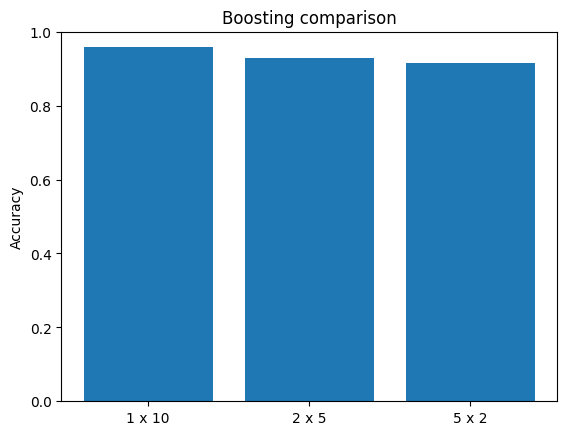

In [ ]:
names = [
    "1 x 10",
    "2 x 5",
    "5 x 2"
]

boost_accuracies = [
    accuracy_boost_1x10,
    accuracy_boost_2x5,
    accuracy_boost_5x2
]

plt.bar(names, boost_accuracies)

plt.ylabel("Accuracy")
plt.title("Boosting comparison")

plt.ylim(0, 1)

plt.show()

## 6. Conclusion

The objective of this exercise was to study whether the organization of an ensemble can influence its performance while keeping the same total number of base learners.

For Random Forest, the experiment was repeated 30 times. The 2 × 5 configuration obtained the highest mean accuracy (0.952) and the lowest variability, although its performance was very close to the 1 × 10 configuration (0.950). The 5 × 2 configuration performed slightly worse (0.937).

For stacking, on the selected train/test split, the 5 × 2 configuration obtained the best accuracy (0.937).

For boosting, the 1 × 10 configuration performed best, with an accuracy of 0.958.

These results show that adding another ensemble level does not automatically improve performance. The effect depends on the ensemble method and on how the base learners are combined.

In a medical classification problem, accuracy is useful for this comparison, but in a real clinical application other measures such as sensitivity and specificity would also be important.